# mag245 n-body digest2 validation (Stages 1–3)

This notebook checks how digest2 and VDP compare on the mag245 n-body benchmark and Sorcha sets, and
explains the differences between them.

- It only **reads** existing results — it does not recompute anything and does not change any
  production file.
- Matched set: benchmark and Sorcha joined on `ObjID == s3m_objid`, Sorcha night **61642**
  (794 NEOs; 1,762 objects across all populations).
- The production files are untouched. New results live in four folders under `outputs/`:
  `digest2_exact_input_audit_night61642/`, `mag245_nbody_deterministic_rescore/`,
  `mag245_nbody_exact_classifier_test/`, `mag245_nbody_synchronized_time_test/`.

**Main findings** (details below):
1. On identical inputs, digest2 scores NEOs better than VDP on all three variants.
2. Most of the benchmark–Sorcha digest2 difference comes from the observation time and the
   magnitude band; what is left over is small.
3. VDP is less sensitive to the observation time than digest2, but has a larger left-over
   difference from rate scatter.
4. In `repeatable` mode digest2 gives the exact same score every time. The odd values in the
   earlier figures came from running it in `random` mode plus two parsing bugs.


## Environment, digest2 configuration, and versions

In [1]:

import os, subprocess, hashlib
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

WORK = Path("/mmfs1/gscratch/dirac/ds2004/sorcha")
EXACT = WORK/"outputs/digest2_exact_input_audit_night61642"
S1 = WORK/"outputs/mag245_nbody_deterministic_rescore"
S2 = WORK/"outputs/mag245_nbody_exact_classifier_test"
S3 = WORK/"outputs/mag245_nbody_synchronized_time_test"
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 40)

def sha16(p): return hashlib.sha256(Path(p).read_bytes()).hexdigest()[:16]

d2 = WORK/"digest2"/"digest2"
ver = subprocess.run([str(d2),"--version"], capture_output=True, text=True).stdout.strip().splitlines()[0]
print("digest2:", ver)
print("  exec sha256[:16]:", sha16(d2), " model sha256[:16]:", sha16(WORK/'digest2'/'digest2.model'))
print("  config: noheadings / norms / repeatable / NEO      obscode: X05")
print("  score parse: int(2nd token)/100, strict (missing->NaN never 0; reject/count out-of-range; --cpu score is cpu-count-independent)")
import astropy, sklearn, assist, rebound, sorcha, adam_core
for m in [np, pd, astropy, sklearn, assist, rebound, sorcha, adam_core]:
    print(f"  {m.__name__}: {m.__version__}")
print("  VDP module: neomod/src/velocity_density_pipeline_gmm.py (n-body integrator, fixing_integrator.md §11)")
print("  VDP maps:", len(list((WORK/'prob_maps_grid_s3m_nbody').glob('*.npz'))),
      "npz in prob_maps_grid_s3m_nbody/  (support_mask_min=1, nearest-dist mask OFF, Johnson V)")


digest2: Digest2 version 0.19 -- Released August 16, 2017 -- Compiled May 28 2026
  exec sha256[:16]: 3182930840cd5ac6  model sha256[:16]: 426fc29e9fcb3baf
  config: noheadings / norms / repeatable / NEO      obscode: X05
  score parse: int(2nd token)/100, strict (missing->NaN never 0; reject/count out-of-range; --cpu score is cpu-count-independent)
  numpy: 2.4.4
  pandas: 3.0.2
  astropy: 7.2.0
  sklearn: 1.8.0
  assist: 1.2.3
  rebound: 4.6.0
  sorcha: 1.1.1
  adam_core: 0.5.5
  VDP module: neomod/src/velocity_density_pipeline_gmm.py (n-body integrator, fixing_integrator.md §11)
  VDP maps: 667 npz in prob_maps_grid_s3m_nbody/  (support_mask_min=1, nearest-dist mask OFF, Johnson V)


## Scripts and how to regenerate

All scripts are under `neomod/pipeline/` (run with `conda_prep/bin/python`). Each stage writes to its
own folder.

| script | what it does |
|---|---|
| `audit_digest2.py` | night-61642 audit: build-pairs / run / combine / report |
| `audit_digest2_exact_input.py` | reruns the same MPC lines twice; compares B/S/V |
| `stage1_deterministic_rescore.py` | Stage 1 rescore of the full sets |
| `stage2_exact_classifier.py` | Stage 2 canonical tracklets + VDP vs digest2 |
| `stage3_synchronized_time.py` | Stage 3 same-time comparison |
| `rescore_vdp_Vband.py` | VDP re-score against a chosen map folder |

```bash
PY=/mmfs1/gscratch/dirac/ds2004/sorcha/conda_prep/bin/python
# Stage 1 (Slurm array 34+33+33, cpu16):
$PY .../stage1_deterministic_rescore.py prep-sorcha-vmags
sbatch --export=ALL,SOURCE=bench         --array=0-33 .../slurm/stage1_deterministic_rescore.sbatch
sbatch --export=ALL,SOURCE=sorcha_rawfix --array=0-32 .../slurm/stage1_deterministic_rescore.sbatch
sbatch --export=ALL,SOURCE=sorcha_vcorr  --array=0-32 .../slurm/stage1_deterministic_rescore.sbatch
for s in bench sorcha_rawfix sorcha_vcorr; do $PY .../stage1_deterministic_rescore.py combine --source $s; $PY .../stage1_deterministic_rescore.py analyze --source $s; done
# Stage 2 (3 VDP re-scores + build):
for s in bench sorcha_rawfix sorcha_vcorr; do sbatch --wrap "$PY .../stage2_exact_classifier.py score-vdp --source $s"; done
for s in bench sorcha_rawfix sorcha_vcorr; do $PY .../stage2_exact_classifier.py build --source $s; done
# Stage 3 (794-NEO pilot):
$PY .../stage3_synchronized_time.py propagate
$PY .../stage3_synchronized_time.py analyze
```


# 1 · Audit integrity — same input gives the same score

For each of the 794 NEOs and each variant (B/S/V), the same two MPC lines were run through digest2
twice in `repeatable` mode. `delta_same_input = |run2 − run1|` should be zero if digest2 is
deterministic.

In [2]:

same = pd.read_csv(EXACT/"same_input_delta_summary.csv")
parse = pd.read_csv(EXACT/"parse_issues.csv")
print("SAME-INPUT reproducibility (identical MPC lines rerun in repeatable mode):")
display(same[["variant","n","median_abs_delta","p95_abs_delta","p99_abs_delta","max_abs_delta",
              "frac_gt_0.05","frac_gt_0.10","missing","duplicate","malformed","out_of_range"]])
print(f"==> max |delta_same_input| across all 794x3 variants = {same.max_abs_delta.max():.4f}  "
      f"(digest2 is PERFECTLY deterministic in repeatable mode; the ±1–3pt jitter was production's random mode)")
print("\nStrict-parse issue counts (per variant):"); display(parse)


SAME-INPUT reproducibility (identical MPC lines rerun in repeatable mode):
==> max |delta_same_input| across all 794x3 variants = 0.0000  (digest2 is PERFECTLY deterministic in repeatable mode; the ±1–3pt jitter was production's random mode)

Strict-parse issue counts (per variant):


,variant,n,median_abs_delta,p95_abs_delta,p99_abs_delta,max_abs_delta,frac_gt_0.05,frac_gt_0.10,missing,duplicate,malformed,out_of_range
0,B,794,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0
1,S,794,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0
2,V,794,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0


,variant,missing,duplicate,malformed,out_of_range
0,B,0,0,0,0
1,S,0,0,0,0
2,V,0,0,0,0


**Result:** every same-input difference is **0.0** (median, p95, p99, max), with no missing,
duplicate, malformed, or out-of-range scores. So in `repeatable` mode digest2 gives the exact same
score every time — any B/S/V difference comes from the input, not from randomness.

The `P_NEO_d2 = 1.17` value and the "1.0 → 0.0" point in the earlier figures were not real digest2
behaviour. They came from running digest2 in `random` mode plus two bugs: a missing score defaulted
to zero, and a raw score above 100 not being capped. A clean rerun gives 1.00.

# 2 · Same-input comparison — VDP vs digest2

Stage 2 builds one tracklet table (ObjID, t0/t1, RA/Dec, magnitudes, filters, obscode, the exact MPC
lines, and a SHA256 of those lines) and scores both classifiers from the same tracklet: digest2 from
the exact MPC lines, VDP from the same tracklet's `vlam/vbeta` and the variant's magnitude against the
n-body maps. Only the magnitude changes between variants. Every MPC-line hash matches Stage 1
(1.96M tracklets, 100%), so both classifiers really do see the same input.

In [3]:

s2 = pd.read_csv(S2/"STAGE2_summary.csv")
show = s2[["source","classifier","n","AUC","bestF1","thresh","completeness","contamination",
           "n_excl_digest2_invalid"]].copy()
display(show)
print("digest2 − VDP on identical inputs:")
for src in ["bench","sorcha_rawfix","sorcha_vcorr"]:
    g = s2[s2.source==src].set_index("classifier")
    print(f"  {src:14s}  ΔAUC={g.loc['digest2_det','AUC']-g.loc['VDP_canon','AUC']:+.3f}  "
          f"ΔF1={g.loc['digest2_det','bestF1']-g.loc['VDP_canon','bestF1']:+.3f}")
# hash verification proof (recomputed vs Stage-1 digest2 input hash)
for src in ["bench","sorcha_rawfix","sorcha_vcorr"]:
    m = pd.read_parquet(S2/f"manifest_{src}.parquet", columns=["hash_matches_stage1"])
    print(f"  {src:14s} hash match: {m.hash_matches_stage1.mean()*100:.4f}%  (n={len(m):,})")


digest2 − VDP on identical inputs:
  bench           ΔAUC=+0.086  ΔF1=+0.071
  sorcha_rawfix   ΔAUC=+0.065  ΔF1=+0.048
  sorcha_vcorr    ΔAUC=+0.067  ΔF1=+0.048
  bench          hash match: 100.0000%  (n=666,786)
  sorcha_rawfix  hash match: 100.0000%  (n=648,769)
  sorcha_vcorr   hash match: 100.0000%  (n=648,769)


,source,classifier,n,AUC,bestF1,thresh,completeness,contamination,n_excl_digest2_invalid
0,bench,digest2_det,666520,0.9527,0.7733,0.930,68.3,10.9,266
1,bench,VDP_canon,666520,0.8665,0.7023,0.940,59.4,14.1,266
2,sorcha_rawfix,digest2_det,648522,0.9434,0.8493,0.610,77.9,6.6,247
3,sorcha_rawfix,VDP_canon,648522,0.8788,0.8017,0.013,74.1,12.7,247
4,sorcha_vcorr,digest2_det,648642,0.9480,0.8500,0.510,78.3,7.0,127
5,sorcha_vcorr,VDP_canon,648642,0.8814,0.8020,0.015,73.6,11.9,127


**Completeness vs contamination (lower-right is better) — digest2 (orange) vs VDP (blue), same inputs:**

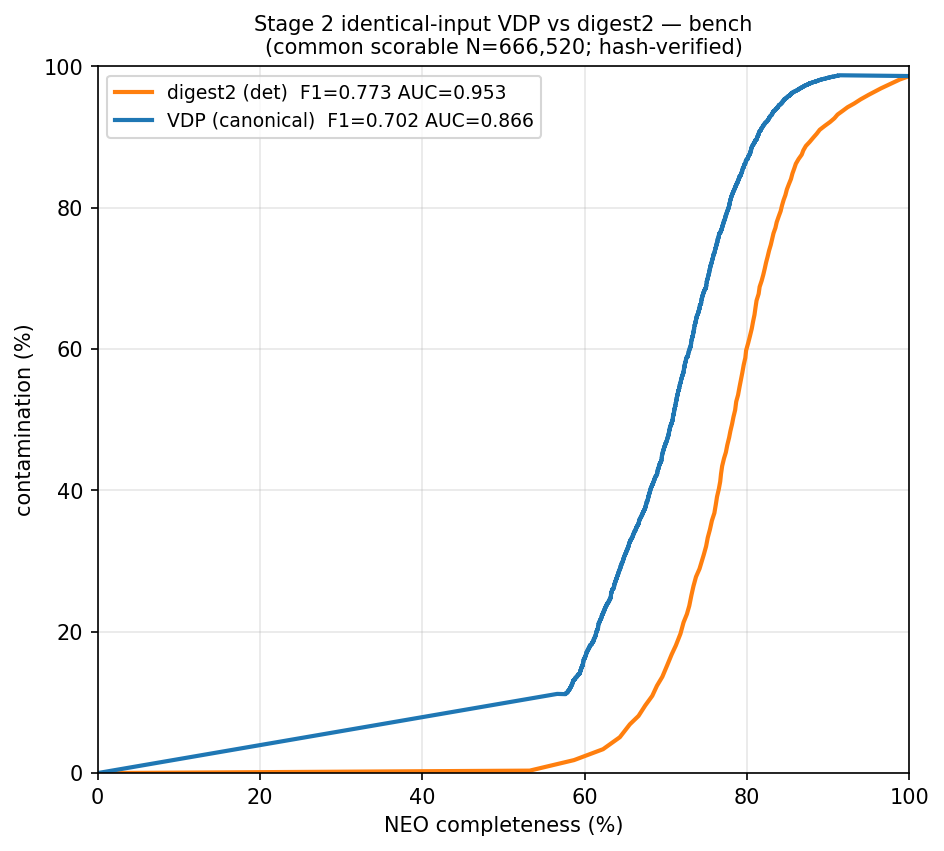

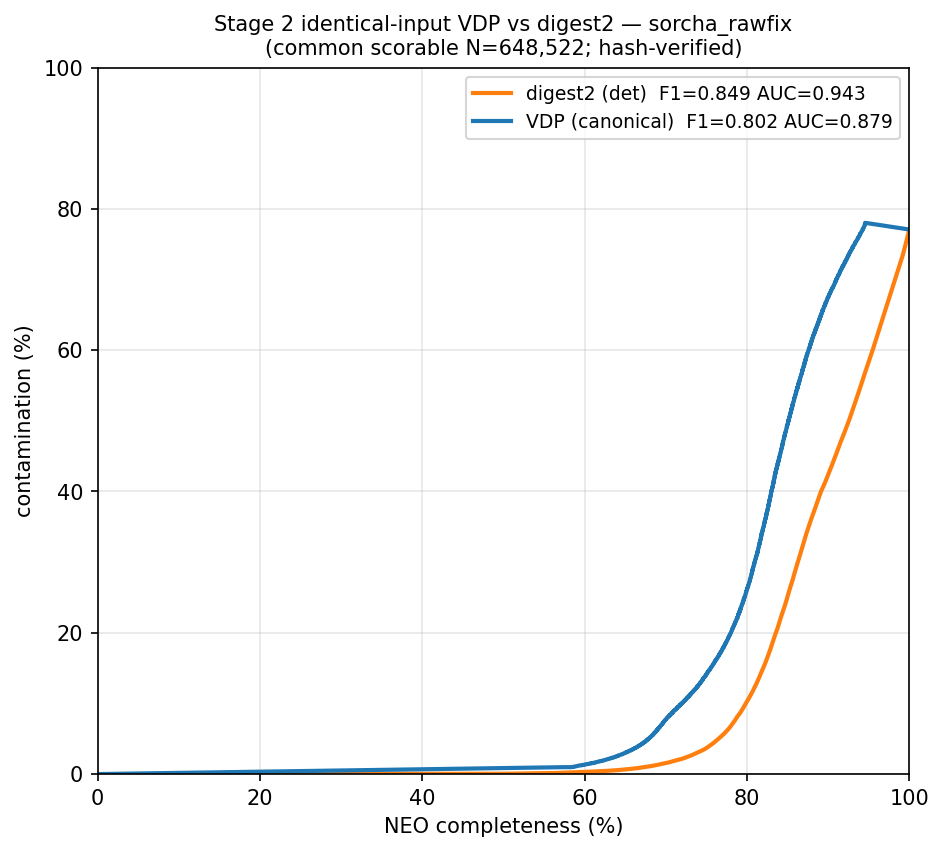

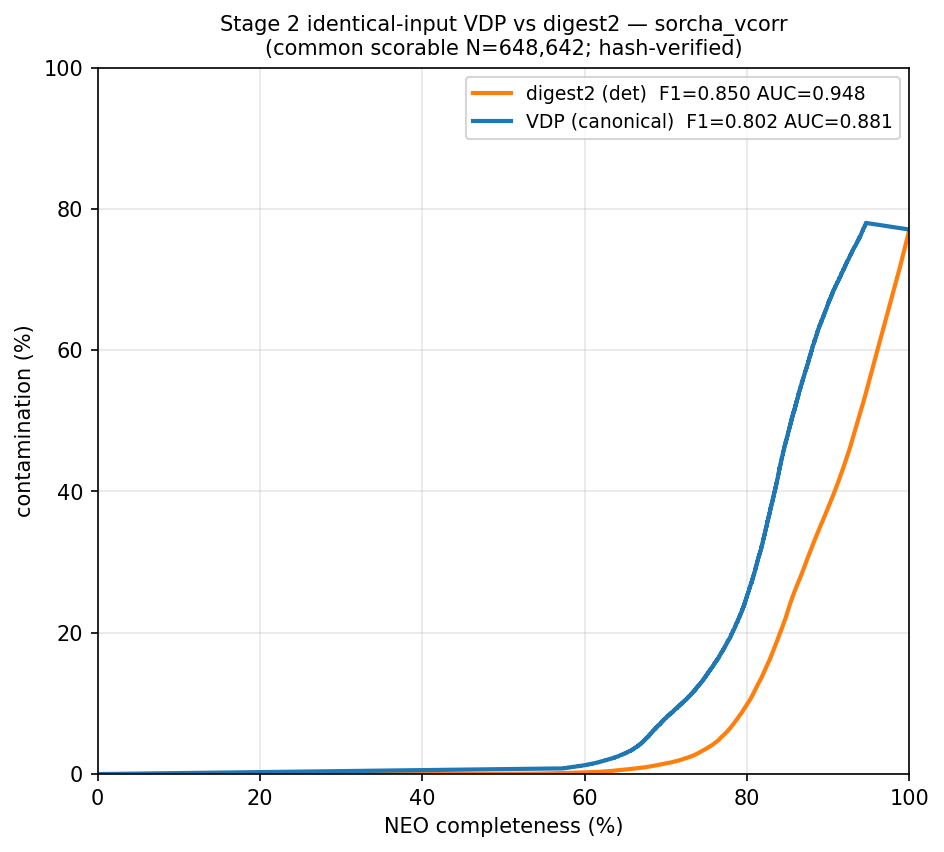

In [4]:

for src in ["bench","sorcha_rawfix","sorcha_vcorr"]:
    display(Image(filename=str(S2/f"roc_{src}.png")))


**Result:** digest2 scores better than VDP on all three variants (AUC higher by 0.065–0.086, F1
higher by 0.05–0.07), and this holds whether the magnitude is raw or V-corrected. The `bench` numbers
match the paper's Figure 2 (digest2 F1 0.773 / AUC 0.953; VDP 0.702 / 0.866). The 127–266 tracklets
per variant that digest2 cannot score are left out of the numbers (not set to zero); VDP scores every
row.

# 3 · Input sensitivity — raw vs V-corrected Sorcha magnitudes

Stage 1 rescores the full sets cleanly. Fixing the digest2 bugs (repeatable mode, careful parsing, no
zero-defaulting) barely changes the overall ROC. The one input change that matters is V-correcting the
Sorcha magnitude. The new column `P_NEO_d2_det` is added to a copy; the production `P_NEO_d2` is left
alone.

In [5]:

s1 = pd.read_csv(S1/"STAGE1_summary.csv")
display(s1[["source","rows","ok","missing","duplicate","malformed","out_of_range",
            "det_AUC","det_F1","dAUC_vs_stored","changed_vs_stored","median_abs_chg","thresh_flips"]])
gr = s1.set_index("source")
print(f"Band effect on Sorcha digest2 (deterministic): AUC {gr.loc['sorcha_rawfix','det_AUC']:.4f} -> "
      f"{gr.loc['sorcha_vcorr','det_AUC']:.4f} ({gr.loc['sorcha_vcorr','det_AUC']-gr.loc['sorcha_rawfix','det_AUC']:+.4f}); "
      f"threshold flips raw->stored {int(gr.loc['sorcha_rawfix','thresh_flips'])}, vcorr {int(gr.loc['sorcha_vcorr','thresh_flips'])}")


Band effect on Sorcha digest2 (deterministic): AUC 0.9434 -> 0.9480 (+0.0046); threshold flips raw->stored 813, vcorr 10960


,source,rows,ok,missing,duplicate,malformed,out_of_range,det_AUC,det_F1,dAUC_vs_stored,changed_vs_stored,median_abs_chg,thresh_flips
0,bench,666786,666520,135,103,28,0,0.9527,0.7733,0.0010,49914,0.00,51
1,sorcha_rawfix,648769,648522,105,80,62,0,0.9434,0.8493,0.0003,72866,0.00,813
2,sorcha_vcorr,648769,648642,37,28,62,0,0.9480,0.8500,0.0049,329001,0.01,10960


**Score-difference distributions** — clean rerun minus stored (bench, Sorcha-raw), and the band shift on its own (Sorcha V − Sorcha raw, both clean reruns):

band (V−raw) Sorcha digest2: median +0.0000, mean -0.0218, |Δ|>0.05 16.7%, |Δ|>0.10 8.8%


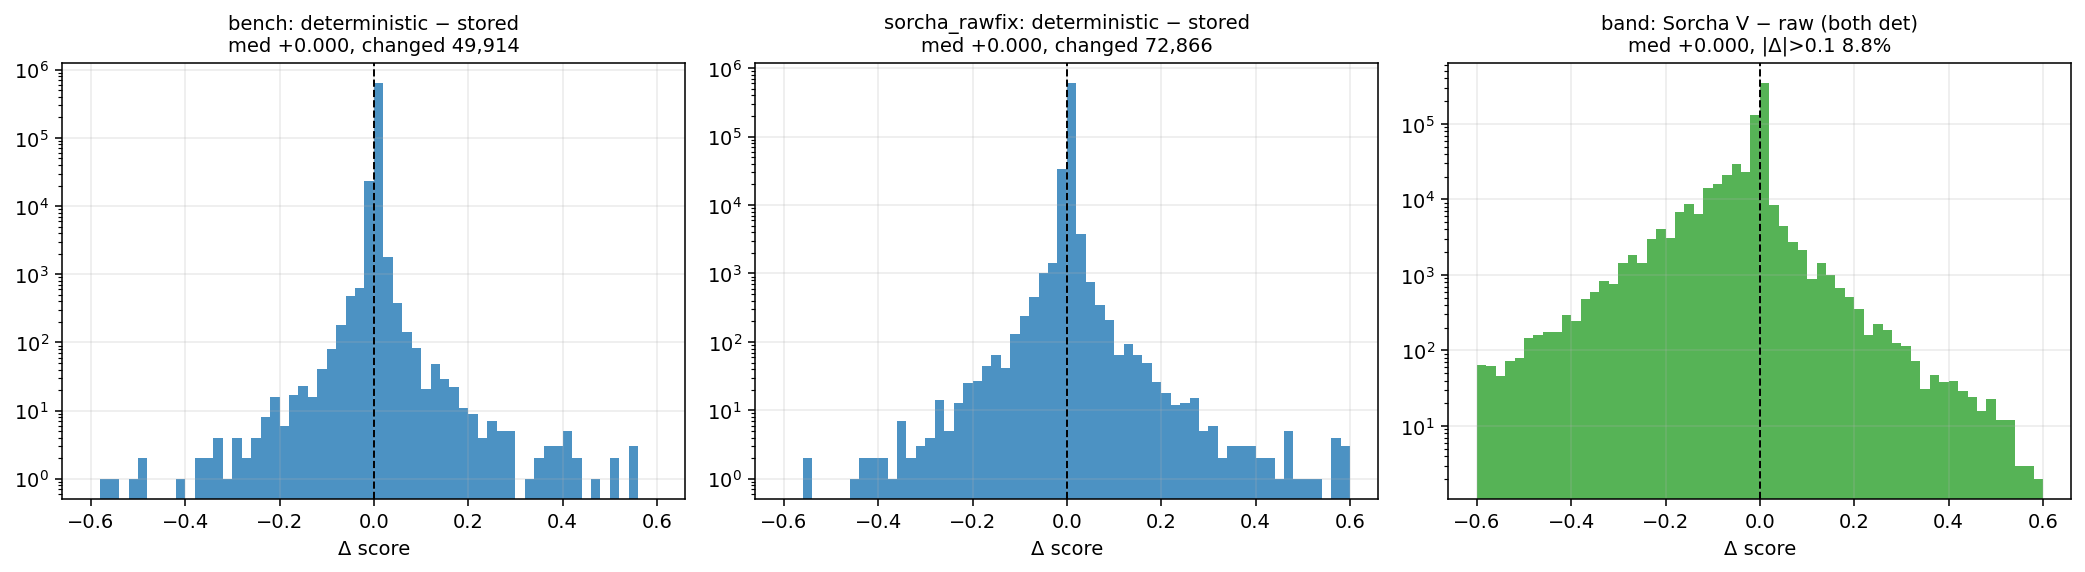

In [6]:

fig, ax = plt.subplots(1, 3, figsize=(15, 4.2)); bins = np.linspace(-0.6, 0.6, 61)
for a, src in zip(ax[:2], ["bench","sorcha_rawfix"]):
    d = pd.read_parquet(S1/f"{src}_scorediff.parquet")
    ch = (d.det - d.stored).dropna()
    a.hist(ch, bins=bins, color="tab:blue", alpha=0.8); a.axvline(0, color="k", ls="--", lw=1)
    a.set_title(f"{src}: deterministic − stored\nmed {ch.median():+.3f}, changed {int((ch.abs()>0).sum()):,}", fontsize=10)
    a.set_xlabel("Δ score"); a.set_yscale("log"); a.grid(alpha=0.25)
raw = pd.read_parquet(S1/"sorcha_rawfix_deterministic.parquet", columns=["P_NEO_d2_det","population"])
vco = pd.read_parquet(S1/"sorcha_vcorr_deterministic.parquet", columns=["P_NEO_d2_det"])
band = (vco.P_NEO_d2_det - raw.P_NEO_d2_det).dropna()
ax[2].hist(band, bins=bins, color="tab:green", alpha=0.8); ax[2].axvline(0, color="k", ls="--", lw=1)
ax[2].set_title(f"band: Sorcha V − raw (both det)\nmed {band.median():+.3f}, |Δ|>0.1 {100*(band.abs()>0.1).mean():.1f}%", fontsize=10)
ax[2].set_xlabel("Δ score"); ax[2].set_yscale("log"); ax[2].grid(alpha=0.25)
plt.tight_layout(); plt.show()
print(f"band (V−raw) Sorcha digest2: median {band.median():+.4f}, mean {band.mean():+.4f}, "
      f"|Δ|>0.05 {100*(band.abs()>0.05).mean():.1f}%, |Δ|>0.10 {100*(band.abs()>0.10).mean():.1f}%")


**Result:** the rerun-minus-stored histograms (log scale) are sharply peaked at 0 with thin
tails — the bug fixes move only a few individual scores (the tails are the recovered zero-defaulted
cases), and the overall AUC barely changes (by at most 0.001). The band shift (V − raw) is wider and
one-sided — the real effect, worth about +0.005 AUC to Sorcha's digest2.

# 4 · Same-time comparison (794 NEOs)

To explain the benchmark–Sorcha differences, each NEO's orbit is propagated (ASSIST n-body, from the
Stage-0 cache) to Sorcha's exact t0 and t1, so the two tracklets are at the same times. Four cases:

- **A** benchmark as-is (fixed epoch, V magnitudes)
- **B** benchmark moved to Sorcha's times (V magnitudes)
- **C** Sorcha, raw magnitudes
- **D** Sorcha, V-corrected magnitudes

Both classifiers, digest2 in repeatable mode.

In [7]:

dec = pd.read_csv(S3/"STAGE3_decomposition.csv")
labels = {"B-A":"time/epoch (B−A)","C-B":"Sorcha meas. raw (C−B)","D-B":"remaining, band-matched V (D−B)","D-C":"band (D−C)"}
dec["effect"] = dec["diff"].map(labels)
display(dec[["effect","classifier","n","mean","p95_abs","p99_abs","max_abs","frac_gt_0_05","frac_gt_0_10"]])
per = pd.read_parquet(S3/"stage3_per_object_794NEO.parquet")
cases = pd.read_parquet(S3/"stage3_cases_794NEO.parquet")
sepA = cases[cases.case=="A"].sky_sep_vs_sorcha_arcsec.median()
sepB = cases[cases.case=="B"].sky_sep_vs_sorcha_arcsec.median()
print(f"\nSky separation benchmark vs Sorcha detection: A (fixed epoch) {sepA:.0f}\"  ->  "
      f"B (synchronized) {sepB:.0f}\"   ({sepA/sepB:.0f}x reduction) — the propagation lines up the positions")



Sky separation benchmark vs Sorcha detection: A (fixed epoch) 259"  ->  B (synchronized) 13"   (20x reduction) — the propagation lines up the positions


,effect,classifier,n,mean,p95_abs,p99_abs,max_abs,frac_gt_0_05,frac_gt_0_10
0,time/epoch (B−A),digest2,794,0.0168,0.1735,0.4214,0.5300,0.1587,0.0894
1,time/epoch (B−A),VDP,794,0.0017,0.0340,0.1525,0.8405,0.0416,0.0264
2,Sorcha meas. raw (C−B),digest2,794,0.0109,0.1000,0.2014,0.4000,0.1184,0.0416
3,Sorcha meas. raw (C−B),VDP,794,0.0089,0.3564,0.8156,1.0000,0.1247,0.1083
4,"remaining, band-matched V (D−B)",digest2,794,-0.0011,0.0400,0.1400,0.2300,0.0378,0.0126
5,"remaining, band-matched V (D−B)",VDP,794,0.0050,0.3515,0.8302,1.0000,0.1121,0.0970
6,band (D−C),digest2,794,-0.0120,0.1000,0.1900,0.3000,0.1134,0.0479
7,band (D−C),VDP,794,-0.0040,0.0732,0.6672,0.9139,0.0542,0.0479


**digest2 score differences, split into time / left-over-V / band:**

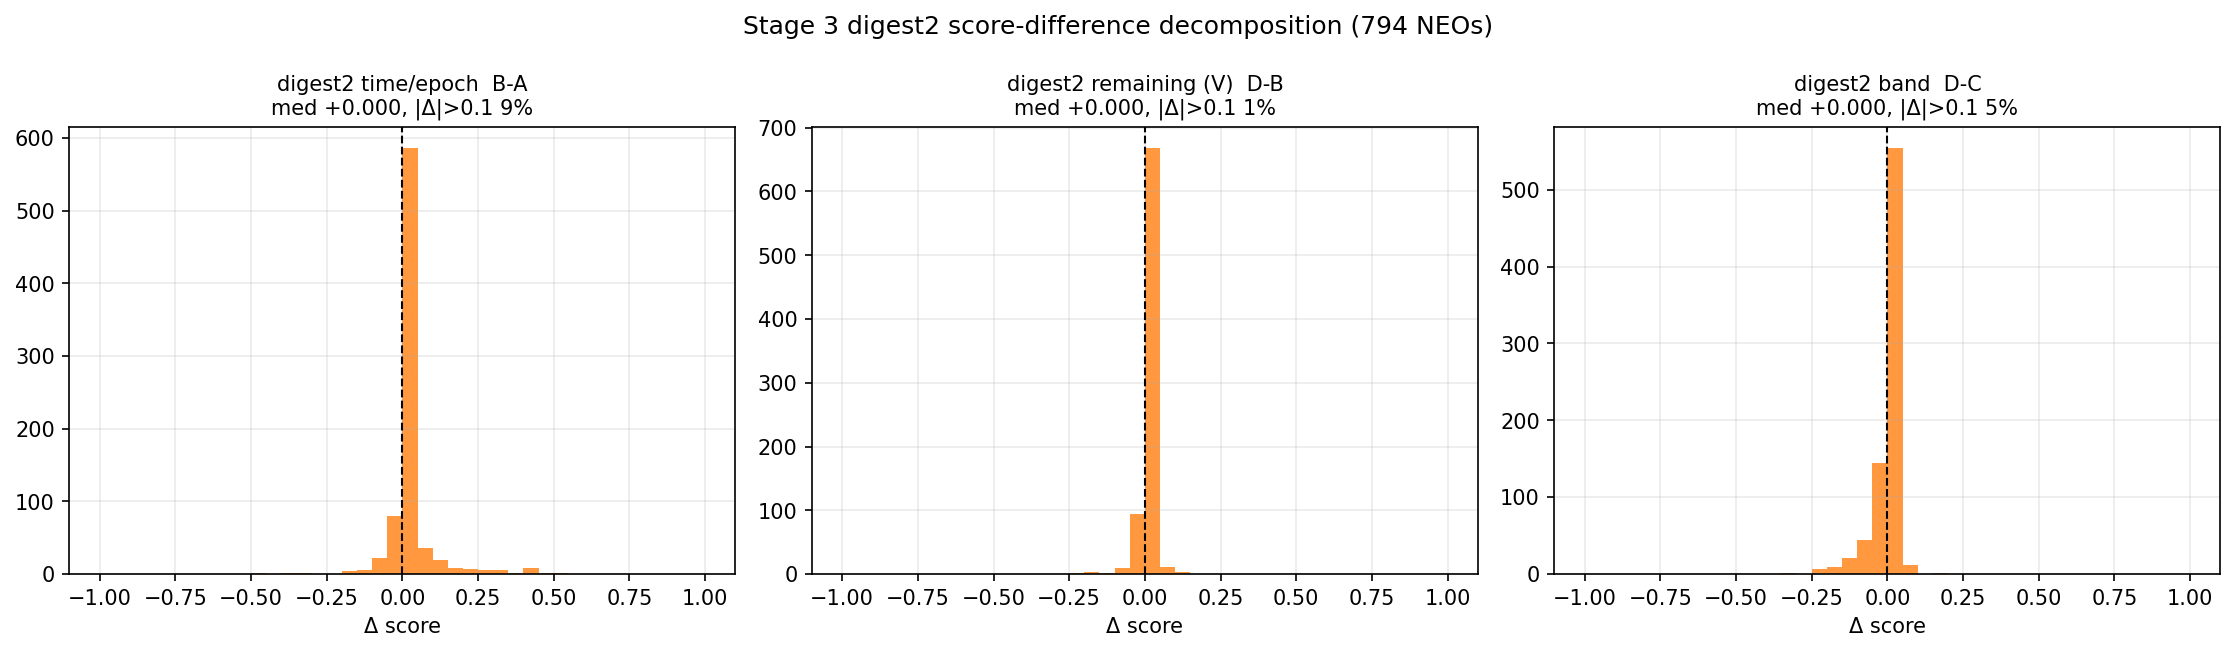

In [8]:
display(Image(filename=str(S3/"stage3_digest2_decomposition_hist.png")))

**Benchmark (A original, B same-time) vs Sorcha (D) digest2 — before and after matching the times:**

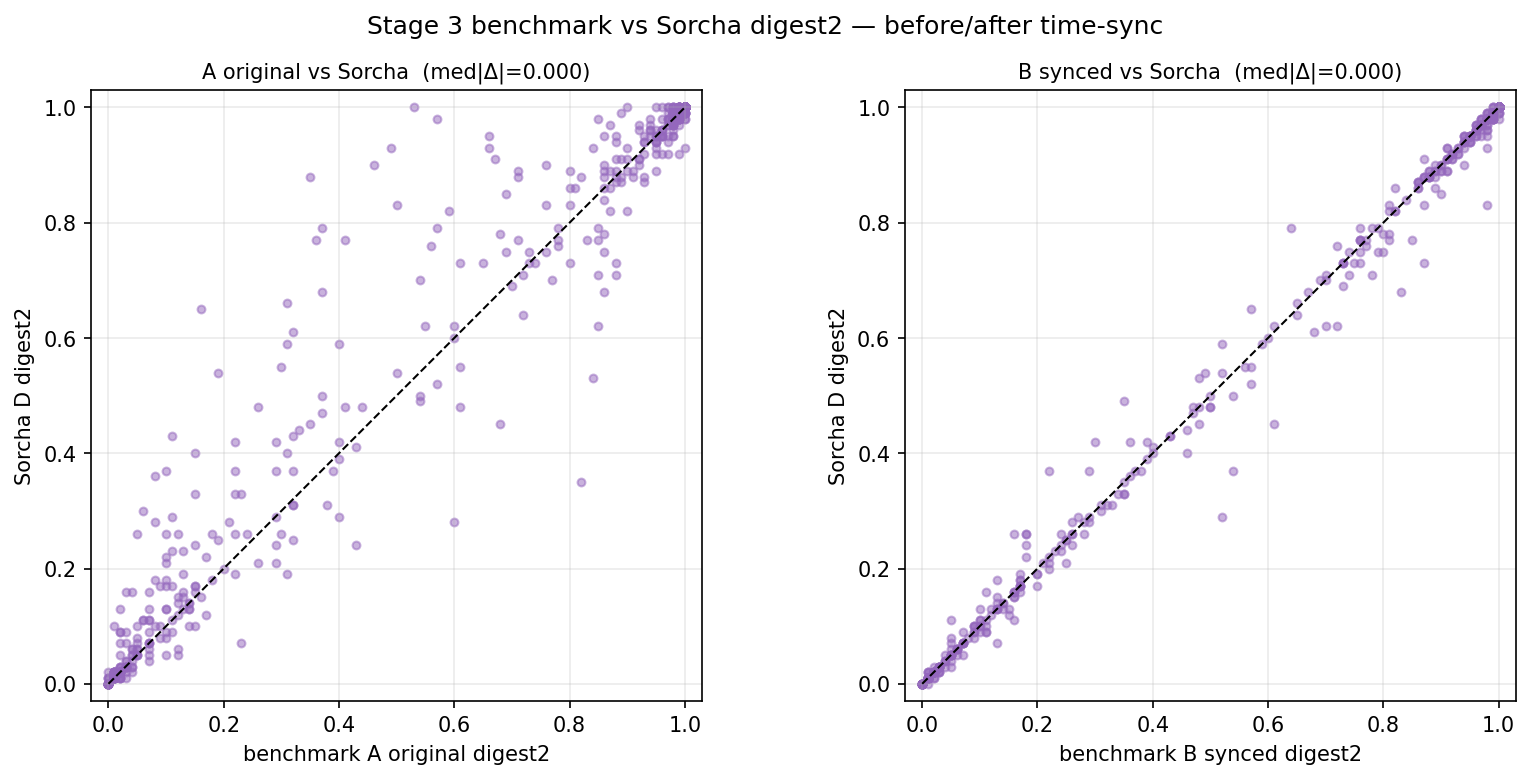

In [9]:
display(Image(filename=str(S3/"stage3_bench_vs_sorcha_scatter.png")))

**Result (digest2):** the benchmark–Sorcha difference is mostly the observation time (B−A: 8.9%
of NEOs move by more than 0.10) plus the magnitude band (D−C: 4.8%). Once both are removed — same
times, both in V (D−B) — what is left is small (mean about 0, only 1.3% move by more than 0.10). So the
differences come from *when* the object was seen and *which band*, not from measurement noise.

**VDP** hardly changes with the observation time (B−A: 2.6% move by more than 0.10) but has a larger
left-over difference (D−B: 9.7%), because its `vlam/vbeta` rates differ between the predicted benchmark
and Sorcha's measurement.

# 5 · Conclusions

1. **On identical inputs, digest2 scores NEOs better than VDP** on all three variants (AUC higher by
   0.065–0.086, F1 higher by 0.05–0.07), whether the magnitude is raw or V-corrected. The `bench`
   numbers match the paper's Figure 2.
2. **The observation time and the magnitude band explain most of the benchmark–Sorcha digest2
   difference.** Matching the times is the biggest effect (8.9% of NEOs move by more than 0.10) and the
   band is second (4.8%); what is left after both is small (1.3%, mean about 0).
3. **VDP is less sensitive to the observation time but has a larger left-over difference.** Its rates
   barely change over the ~0.4-day gap, but they differ between the predicted benchmark and Sorcha's
   measurement, leaving about 10% of objects moving by more than 0.10.
4. **Same input, same score.** In `repeatable` mode digest2 is exactly reproducible. The earlier
   figures used `random` mode (which adds 1–3 point jitter) plus two bugs — a missing score defaulted
   to zero, and a raw score above 100 not capped. Fixing these barely changes the overall ROC; the
   magnitude band is the one input change that matters.

**Not run yet:** the full 1,762-object version of the same-time comparison (Section 4, all
populations). The production files are untouched throughout.